# 02. Feature Engineering : 분할 고정과 피처 세트 사전 점검

- **이 노트북은 Batch 1 의 train 부분만 쓴다.** Hold-out(Valid) 과 Batch 2·3 은 여기서 평가하지 않는다.
- 목적 : DAY 1 전략의 피처 세트·후보 모델이 Batch 1 교차검증에서 어떤 수준인지 미리 본다.

In [1]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.font_manager as fm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, GroupKFold
from xgboost import XGBRegressor
from split import split_b1, holdout_policies, SEED

FONT = '/System/Library/Fonts/AppleSDGothicNeo.ttc'
fm.fontManager.addfont(FONT)
plt.rcParams['font.family'] = fm.FontProperties(fname=FONT).get_name()
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.spines.top'] = False; plt.rcParams['axes.spines.right'] = False
FIG = '../results/figures'

df = pd.read_csv('../results/cell_features.csv')
b1 = df[df.batch == 'b1'].reset_index(drop=True)
train, valid = split_b1(b1)
print('hold-out 정책 :', holdout_policies(b1))
print(f'train {len(train)} 셀 / {train.policy.nunique()} 정책,  valid {len(valid)} 셀 / {valid.policy.nunique()} 정책')
print('train life :', train.life.describe()[['min', '50%', 'max']].to_dict())
print('valid life :', valid.life.describe()[['min', '50%', 'max']].to_dict())

hold-out 정책 : ['4.4C(80%)-4.4C', '4.8C(80%)-4.8C', '5.4C(60%)-3C', '5.4C(80%)-5.4C', '6C(50%)-3C']
train 32 셀 / 17 정책,  valid 9 셀 / 5 정책
train life : {'min': 599.0, '50%': 815.0, 'max': 2237.0}
valid life : {'min': 534.0, '50%': 860.0, 'max': 1074.0}


## 피처 세트

In [2]:
DQ = ['dq_var', 'dq_min', 'dq_mean', 'dq_skew', 'dq_kurt']
# 논문 Supplementary Table 1 과 같은 구성 : discharge 후보 13개, full 후보 20개
CAP = ['qd_c2', 'qd_max_minus_c2', 'qd_c100', 'fade_slope_2_100', 'fade_int_2_100', 'fade_slope_91_100', 'fade_int_91_100']
OTHER = ['chargetime_avg_2_6', 'tmax_max', 'tmin_min', 'tavg_mean', 'ir_c2', 'ir_min', 'ir_c100_minus_c2']
FSETS = {
    'F1 분산': ['dq_var'],
    'F2 ΔQ 통계량': DQ,
    'F3 논문 discharge 후보': DQ + ['dq_2v'] + CAP,
    'F4 논문 full 후보': DQ + ['dq_2v'] + CAP + OTHER,
}
for k, v in FSETS.items(): print(k, v)

F1 분산 ['dq_var']
F2 ΔQ 통계량 ['dq_var', 'dq_min', 'dq_mean', 'dq_skew', 'dq_kurt']
F3 논문 discharge 후보 ['dq_var', 'dq_min', 'dq_mean', 'dq_skew', 'dq_kurt', 'dq_2v', 'qd_c2', 'qd_max_minus_c2', 'qd_c100', 'fade_slope_2_100', 'fade_int_2_100', 'fade_slope_91_100', 'fade_int_91_100']
F4 논문 full 후보 ['dq_var', 'dq_min', 'dq_mean', 'dq_skew', 'dq_kurt', 'dq_2v', 'qd_c2', 'qd_max_minus_c2', 'qd_c100', 'fade_slope_2_100', 'fade_int_2_100', 'fade_slope_91_100', 'fade_int_91_100', 'chargetime_avg_2_6', 'tmax_max', 'tmin_min', 'tavg_mean', 'ir_c2', 'ir_min', 'ir_c100_minus_c2']


## 후보 모델 : 정책 단위 GroupKFold(5), 튜닝은 각 폴드 안의 내부 GroupKFold(4) 로 (nested)

In [3]:
def mape(y_true_log, y_pred_log):
    t, p = 10 ** y_true_log, 10 ** y_pred_log
    return np.mean(np.abs(p - t) / t) * 100

def scaled(est):
    return Pipeline([('sc', StandardScaler()), ('m', est)])

MODELS = {
    'Linear': (scaled(LinearRegression()), None),
    'ElasticNet': (scaled(ElasticNet(max_iter=50000, random_state=SEED)),
                   {'m__alpha': np.logspace(-4, 0, 13), 'm__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]}),
    'Ridge': (scaled(Ridge()), {'m__alpha': np.logspace(-3, 2, 16)}),
    'Lasso': (scaled(Lasso(max_iter=50000)), {'m__alpha': np.logspace(-4, 0, 13)}),
    'RandomForest': (RandomForestRegressor(n_estimators=300, random_state=SEED),
                     {'min_samples_leaf': [1, 2, 4], 'max_features': [0.5, 1.0]}),
    'XGBoost': (XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=SEED, verbosity=0),
                {'max_depth': [2, 3], 'min_child_weight': [1, 3]}),
}

outer = GroupKFold(n_splits=5)
y = train.log_life.values; g = train.policy.values
rows = []
for fs, cols in FSETS.items():
    X = train[cols].values
    for name, (est, grid) in MODELS.items():
        scores, fold_pred = [], np.zeros(len(y))
        for tr, te in outer.split(X, y, g):
            if grid:
                model = GridSearchCV(est, grid, cv=GroupKFold(n_splits=4), scoring='neg_mean_absolute_error')
                model.fit(X[tr], y[tr], groups=g[tr])
            else:
                model = est.fit(X[tr], y[tr])
            p = model.predict(X[te]); fold_pred[te] = p
            scores.append(mape(y[te], p))
        rows.append({'feature_set': fs, 'model': name, 'cv_mape': np.mean(scores), 'cv_std': np.std(scores),
                     'n_feat': len(cols)})
cv = pd.DataFrame(rows)
table = cv.pivot(index='model', columns='feature_set', values='cv_mape').round(1)
table = table[list(FSETS)]
table

feature_set,F1 분산,F2 ΔQ 통계량,F3 논문 discharge 후보,F4 논문 full 후보
model,,,,
ElasticNet,9.0,10.3,9.0,9.3
Lasso,9.0,9.4,9.2,9.5
Linear,8.9,11.3,15.4,121.1
RandomForest,15.3,12.6,13.0,15.6
Ridge,9.0,10.8,11.1,11.7
XGBoost,16.4,15.7,14.3,13.5


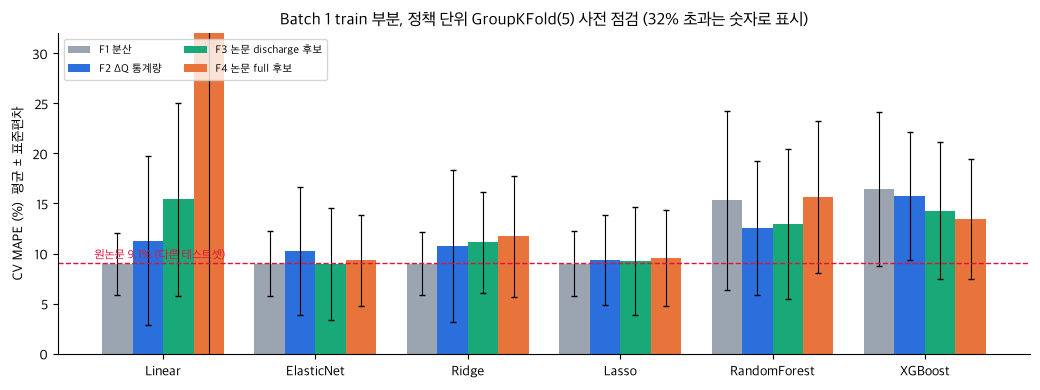

In [4]:
fig, ax = plt.subplots(figsize=(10.5, 4))
models = list(MODELS); w = 0.2
colors_ = ['#9aa5b1', '#2a6fdb', '#19a979', '#e8743b']
for i, fs in enumerate(FSETS):
    sub = cv[cv.feature_set == fs].set_index('model').loc[models]
    ax.bar(np.arange(len(models)) + (i - 1.5) * w, sub.cv_mape, w, yerr=sub.cv_std, capsize=2,
           color=colors_[i], label=fs, error_kw=dict(lw=0.8))
ax.axhline(9.1, color='crimson', ls='--', lw=1); ax.text(-0.45, 9.5, '원논문 9.1% (다른 테스트셋)', color='crimson', fontsize=8.5, ha='left')
ax.set_xticks(range(len(models))); ax.set_xticklabels(models)
ax.set_ylabel('CV MAPE (%)  평균 ± 표준편차'); ax.legend(fontsize=8, ncol=2, loc='upper left')
ax.set_ylim(0, 32)
for i, fs in enumerate(FSETS):
    sub = cv[cv.feature_set == fs].set_index('model').loc[models]
    for j, (m, v) in enumerate(sub.cv_mape.items()):
        if v > 32: ax.text(j + (i - 1.5) * w, 30.5, f'{v:.0f}', ha='center', fontsize=7, color='crimson')
ax.set_title('Batch 1 train 부분, 정책 단위 GroupKFold(5) 사전 점검 (32% 초과는 숫자로 표시)')
plt.tight_layout(); plt.savefig(f'{FIG}/prelim_cv.png', bbox_inches='tight'); plt.show()
cv.round(2).to_csv('../results/prelim_cv.csv', index=False)

## 기준선 : 학습 평균으로 예측 (논문의 naive 기준선과 같은 방식)

In [5]:
ap = []
for tr_i, te_i in GroupKFold(n_splits=5).split(train, y, g):
    t = 10 ** y[te_i]; p = 10 ** y[tr_i].mean()
    ap.append(np.mean(np.abs(p - t) / t) * 100)
print(f'학습 평균 기준선 CV MAPE : {np.mean(ap):.1f} ± {np.std(ap):.1f}')

학습 평균 기준선 CV MAPE : 28.3 ± 8.4


## 정책 단위 분할과 무작위 분할의 차이 (누수 점검)

같은 정책 셀이 train·valid 에 함께 들어가면 CV 성능이 낙관적으로 나오는지 ElasticNet F3 로 확인한다.

In [6]:
from sklearn.model_selection import KFold
X = train[FSETS['F3 논문 discharge 후보']].values
est, grid = MODELS['ElasticNet']
res = {}
for label, splitter, groups in [('정책 단위 GroupKFold', GroupKFold(5), g), ('무작위 KFold', KFold(5, shuffle=True, random_state=SEED), None)]:
    sc = []
    for tr, te in splitter.split(X, y, groups):
        inner = GroupKFold(4) if groups is not None else KFold(4, shuffle=True, random_state=SEED)
        m = GridSearchCV(est, grid, cv=inner, scoring='neg_mean_absolute_error')
        m.fit(X[tr], y[tr], **({'groups': g[tr]} if groups is not None else {}))
        sc.append(mape(y[te], m.predict(X[te])))
    res[label] = (np.mean(sc), np.std(sc))
pd.DataFrame(res, index=['cv_mape', 'cv_std']).T.round(2)

,cv_mape,cv_std
정책 단위 GroupKFold,8.97,5.60
무작위 KFold,10.25,5.94
